In [28]:
# Import required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load iris dataset from seaborn
df = sns.load_dataset('iris')

# Display first 5 rows
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [29]:
df['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [30]:
# Import train test split
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop('species', axis=1)
y = df['species']

In [31]:
X_train , X_test , y_train , y_test = train_test_split(
    X,y , test_size=0.33 , random_state=42
)

In [32]:
from sklearn.neighbors import KNeighborsClassifier

In [33]:
# 4. Initialize and Fit the model
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train, y_train)

KNeighborsClassifier()

In [34]:
model_knn.score(X_test, y_test)

0.98

In [35]:
from sklearn.svm import SVC

#model_svm = SVC(C = 10,kernel='rbf',gamma= 'auto')
model_svm = SVC(gamma= 'auto')

In [36]:
model_svm.fit(X_train, y_train)

SVC(gamma='auto')

In [37]:
model_svm.score(X_test, y_test)

1.0

In [38]:
#now lets use grid seach cv

In [39]:
from sklearn.model_selection import GridSearchCV

In [40]:
# 2. Initialize GridSearchCV
# Using the SVM model (model_svm) from your previous step
classifier = GridSearchCV(model_svm,{
    'C':[1,10,20,30],
    'kernel':['rbf','linear']
},cv = 5 , return_train_score = False)

In [41]:
# 3. Run the grid search
classifier.fit(X, y)

GridSearchCV(cv=5, estimator=SVC(gamma='auto'),
             param_grid={'C': [1, 10, 20, 30], 'kernel': ['rbf', 'linear']})

In [42]:

classifier.cv_results_

{'mean_fit_time': array([0.00426989, 0.00552001, 0.00609598, 0.00595045, 0.00493641,
        0.00390892, 0.00395951, 0.00352068]),
 'std_fit_time': array([0.00013054, 0.00225425, 0.0021269 , 0.00269427, 0.00106707,
        0.00021329, 0.00015496, 0.0001739 ]),
 'mean_score_time': array([0.00379043, 0.00406766, 0.00502   , 0.00304689, 0.00387845,
        0.00287256, 0.0029573 , 0.00274315]),
 'std_score_time': array([1.52350169e-03, 1.87584681e-03, 1.98396700e-03, 6.21582350e-04,
        1.10725634e-03, 7.40566025e-05, 1.20017118e-04, 1.83867233e-04]),
 'param_C': masked_array(data=[1, 1, 10, 10, 20, 20, 30, 30],
              mask=[False, False, False, False, False, False, False, False],
        fill_value=999999),
 'param_kernel': masked_array(data=['rbf', 'linear', 'rbf', 'linear', 'rbf', 'linear',
                    'rbf', 'linear'],
              mask=[False, False, False, False, False, False, False, False],
        fill_value=np.str_('?'),
             dtype=object),
 'params': [

In [43]:
results = pd.DataFrame(classifier.cv_results_)
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004270,0.000131,0.003790,0.001524,1,rbf,"{'C': 1, 'kernel': 'rbf'}",0.966667,1.0,0.966667,0.966667,1.0,0.980000,0.016330,1
1,0.005520,0.002254,0.004068,0.001876,1,linear,"{'C': 1, 'kernel': 'linear'}",0.966667,1.0,0.966667,0.966667,1.0,0.980000,0.016330,1
2,0.006096,0.002127,0.005020,0.001984,10,rbf,"{'C': 10, 'kernel': 'rbf'}",0.966667,1.0,0.966667,0.966667,1.0,0.980000,0.016330,1
3,0.005950,0.002694,0.003047,0.000622,10,linear,"{'C': 10, 'kernel': 'linear'}",1.000000,1.0,0.900000,0.966667,1.0,0.973333,0.038873,4
4,0.004936,0.001067,0.003878,0.001107,20,rbf,"{'C': 20, 'kernel': 'rbf'}",0.966667,1.0,0.900000,0.966667,1.0,0.966667,0.036515,5
5,0.003909,0.000213,0.002873,0.000074,20,linear,"{'C': 20, 'kernel': 'linear'}",1.000000,1.0,0.900000,0.933333,1.0,0.966667,0.042164,6
6,0.003960,0.000155,0.002957,0.000120,30,rbf,"{'C': 30, 'kernel': 'rbf'}",0.966667,1.0,0.900000,0.933333,1.0,0.960000,0.038873,7
7,0.003521,0.000174,0.002743,0.000184,30,linear,"{'C': 30, 'kernel': 'linear'}",1.000000,1.0,0.900000,0.900000,1.0,0.960000,0.048990,7


In [44]:
results[['param_C','param_kernel','mean_test_score']]

,param_C,param_kernel,mean_test_score
0,1,rbf,0.980000
1,1,linear,0.980000
2,10,rbf,0.980000
3,10,linear,0.973333
4,20,rbf,0.966667
5,20,linear,0.966667
6,30,rbf,0.960000
7,30,linear,0.960000


#random search cv


In [45]:
from sklearn.model_selection import RandomizedSearchCV

In [46]:
classifier_r = RandomizedSearchCV(model_svm,{
    'C':[1,10,20,30],
    'kernel':['rbf','linear']
},n_iter = 4,cv = 5 , return_train_score = False)

In [47]:
classifier_r.fit(X, y)

RandomizedSearchCV(cv=5, estimator=SVC(gamma='auto'), n_iter=4,
                   param_distributions={'C': [1, 10, 20, 30],
                                        'kernel': ['rbf', 'linear']})

In [48]:
results = pd.DataFrame(classifier_r.cv_results_)
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_kernel,param_C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004331,0.000622,0.002958,0.000103,linear,10,"{'kernel': 'linear', 'C': 10}",1.000000,1.0,0.900000,0.966667,1.0,0.973333,0.038873,2
1,0.005684,0.003076,0.003994,0.002466,linear,30,"{'kernel': 'linear', 'C': 30}",1.000000,1.0,0.900000,0.900000,1.0,0.960000,0.048990,3
2,0.007966,0.003557,0.005871,0.003922,rbf,30,"{'kernel': 'rbf', 'C': 30}",0.966667,1.0,0.900000,0.933333,1.0,0.960000,0.038873,3
3,0.004591,0.000168,0.003359,0.000056,rbf,1,"{'kernel': 'rbf', 'C': 1}",0.966667,1.0,0.966667,0.966667,1.0,0.980000,0.016330,1


In [49]:
results[['param_C','param_kernel','mean_test_score']]

,param_C,param_kernel,mean_test_score
0,10,linear,0.973333
1,30,linear,0.960000
2,30,rbf,0.960000
3,1,rbf,0.980000


#**ensemble** **learning**

#stacking



In [50]:
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

import seaborn as sns

# Load iris dataset
df = sns.load_dataset('iris')

# Display first 5 rows
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [51]:
X = df.drop('species', axis=1)
y = df['species']

In [52]:
# Encode target labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [54]:
# Base learners
base_learners = [
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('svc', SVC(probability=True, kernel='rbf', random_state=42)),
    ('lr', LogisticRegression(max_iter=1000))
]


In [55]:

# Meta learner
meta_learner = LogisticRegression(max_iter=1000)

# Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5
)

In [56]:
stacking_clf.fit(X_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('dt', DecisionTreeClassifier(random_state=42)),
                               ('svc', SVC(probability=True, random_state=42)),
                               ('lr', LogisticRegression(max_iter=1000))],
                   final_estimator=LogisticRegression(max_iter=1000))

In [57]:
# Predictions
y_pred = stacking_clf.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print(classification_report(y_test, y_pred))

Accuracy: 0.9666666666666667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



#**bagging / random forest**

In [58]:
# Import Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,   # Number of trees
    max_depth=None,     # Let trees grow fully
    random_state=42
)

In [59]:
# Train Random Forest model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)


In [60]:
print("Accuracy:", accuracy_score(y_test, y_pred))

# Detailed report
print(classification_report(y_test, y_pred))

Accuracy: 0.9
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.82      0.90      0.86        10
           2       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



#**Boosting**

1- adabbost
2- gradient boost
3- xg boost


# **Xg , Ada boost**

In [61]:
# Import Boosting algorithms
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

# Import XGBoost classifier
from xgboost import XGBClassifier

In [62]:
ada_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)


In [63]:
# Train model
ada_model.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=100, random_state=42)

In [64]:
# Make predictions
y_pred = ada_model.predict(X_test)

In [65]:

# Check accuracy
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9333333333333333


In [66]:

# Detailed report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [67]:
# Create Gradient Boosting model
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

In [68]:

# Train model
gb_model.fit(X_train, y_train)

# Make predictions
y_pred = gb_model.predict(X_test)

In [69]:
# Check accuracy
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

# Detailed report
print(classification_report(y_test, y_pred))

Accuracy: 0.9666666666666667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [70]:
# Create XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric='mlogloss'
)


In [71]:
# Train model
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [72]:
# Make predictions
y_pred = xgb_model.predict(X_test)

In [73]:
# Check accuracy
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

# Detailed report
print(classification_report(y_test, y_pred))

Accuracy: 0.9333333333333333
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [74]:
# =========================
# Compare All Models
# =========================

from sklearn.metrics import accuracy_score
import pandas as pd

# Dictionary of models
models = {
    "Random Forest": rf_model,
    "AdaBoost": ada_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model
}

# Store results
results = []

# Evaluate each model
for name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    # Store results
    results.append([name, acc])

# Create dataframe
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy'])

# Sort by accuracy
results_df = results_df.sort_values(by='Accuracy', ascending=False)

# Display results
results_df

,Model,Accuracy
2,Gradient Boosting,0.966667
1,AdaBoost,0.933333
3,XGBoost,0.933333
0,Random Forest,0.900000


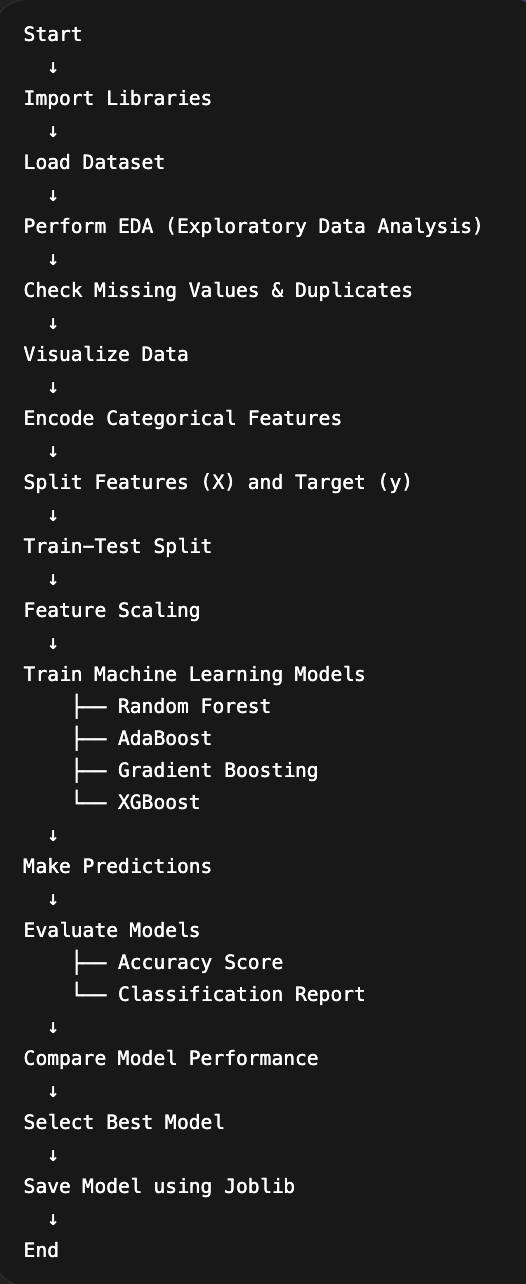

